<a href="https://colab.research.google.com/github/Pedrohsm2/Projeto-Prog-1/blob/master/atividade_pratica_aula5_visualizacao_matplotlib_seaborn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Atividade Prática — Aula 5: Visualização de Dados para Decisões com Matplotlib e Seaborn

Esta atividade foi construída com base nos slides da Aula 5, cujo foco é transformar dados limpos em **gráficos que apoiem decisões**, e não em imagens decorativas. A aula reforça que o bom gráfico reduz esforço cognitivo, responde uma pergunta de negócio e precisa ser claro, comparável, simples e honesto. fileciteturn6file0

## Regras desta atividade
- Você deve **construir os códigos**.
- O notebook orienta os passos, mas não entrega a solução pronta.
- Após cada gráfico principal, escreva uma **interpretação curta** em markdown.
- O gráfico deve ser tratado como parte do seu portfólio: título, unidade, ordenação e mensagem importam. fileciteturn6file0

## Dataset da atividade
Arquivo: `vendas_brasil_clean_aula5.csv`


## 1. Preparação do ambiente

Importe as bibliotecas necessárias para trabalhar com:
- manipulação de dados
- gráficos com Matplotlib
- gráficos com Seaborn

**Sugestão:**
- `pandas`
- `matplotlib.pyplot`
- `seaborn`


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


## 2. Leitura da base

Leia o arquivo `vendas_brasil_clean_aula5.csv` em um DataFrame chamado `df`.

Depois:
1. exiba as primeiras linhas
2. verifique o tamanho da base
3. confira os tipos das colunas
4. observe quais variáveis podem ser usadas para:
   - comparação
   - tendência
   - distribuição
   - relação entre métricas


In [2]:
df = pd.read_csv('vendas_brasil_clean_aula5.csv')


## 3. Traduzindo a pergunta em gráfico

A aula destaca que a escolha do gráfico nunca é aleatória: a pergunta define a visualização. fileciteturn6file0

### Tarefa
Preencha em markdown pelo menos 4 exemplos no formato:

- **Pergunta do gestor:** ...
- **Variáveis (Pandas):** ...
- **Tipo de gráfico:** ...
- **Biblioteca sugerida:** ...

Use como referência a matriz mostrada nos slides:
- evolução no tempo → linha
- ranking/comparação entre grupos → barras
- variabilidade e outliers → boxplot
- correlação entre duas métricas → scatter


### Exemplo 1
**Pergunta do gestor:** Como a receita evoluiu ao longo do tempo?  
**Variáveis (Pandas):** data, receita  
**Tipo de gráfico:** linha  
**Biblioteca sugerida:** matplotlib  

---

### Exemplo 2
**Pergunta do gestor:** Qual canal vende mais?  
**Variáveis (Pandas):** canal, receita  
**Tipo de gráfico:** barras  
**Biblioteca sugerida:** seaborn  

---

### Exemplo 3
**Pergunta do gestor:** Existe muita variação no valor das vendas?  
**Variáveis (Pandas):** valor_venda  
**Tipo de gráfico:** boxplot  
**Biblioteca sugerida:** seaborn  

---

### Exemplo 4
**Pergunta do gestor:** Existe relação entre desconto e receita?  
**Variáveis (Pandas):** desconto, receita  
**Tipo de gráfico:** scatter (dispersão)  
**Biblioteca sugerida:** matplotlib  

## 4. Gráfico de barras horizontais — Qual canal gera mais caixa?

A missão prática do slide pede responder: **qual canal gera mais caixa?** fileciteturn6file0

### Tarefa
1. Agrupe a receita por `canal_venda`
2. Ordene os valores
3. Gere um gráfico de **barras horizontais**
4. Use rótulos e título claros
5. Certifique-se de que a visualização esteja limpa e fácil de ler

### Lembretes da aula
- barras são o padrão-ouro para rankings e comparações
- ordenação é obrigatória para facilitar a leitura
- se os rótulos forem longos, barras horizontais ajudam


In [3]:
receita_canal = df.groupby('canal_venda')['receita'].sum()


In [4]:
receita_canal = receita_canal.sort_values()

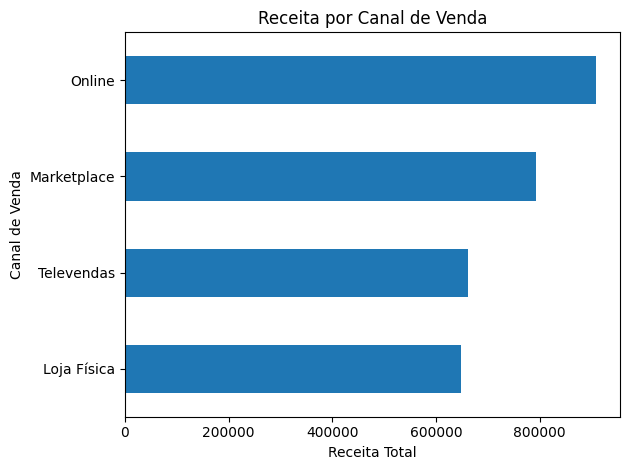

In [7]:
plt.figure()
receita_canal.plot(kind='barh')

plt.title('Receita por Canal de Venda')
plt.xlabel('Receita Total')
plt.ylabel('Canal de Venda')

plt.tight_layout()
plt.show()

### Insight obrigatório
Escreva 2 ou 3 linhas explicando:
- qual canal lidera
- qual canal fica atrás
- que ação tática um gestor poderia considerar a partir disso


O canal que lidera é o online e o que está em ultimo é o das lojas físicas. Podemos concluir que os canais de vendas mais utilizados são pela internet e que fisicamente as lojas estão mais atrás.

## 5. Gráfico de linha — Como é a sazonalidade ao longo dos meses?

Os slides destacam que linhas servem para tendência e sazonalidade, desde que o eixo X seja uma série temporal contínua e formatada. fileciteturn6file0

### Tarefa
1. Agrupe a `receita` por `mes`
2. Gere um gráfico de linha temporal
3. Remova ruídos visuais desnecessários
4. Use um título que diga **o que aconteceu**, não apenas o nome das colunas

### Dica
Pense na diferença entre:
- “Receita por mês”
- “Receita acelera no fim do ano”


In [8]:
df['data'] = pd.to_datetime(df['data'], errors='coerce')


In [9]:
df['mes'] = df['data'].dt.to_period('M')

In [10]:
receita_mes = df.groupby('mes')['receita'].sum()
receita_mes.index = receita_mes.index.to_timestamp()


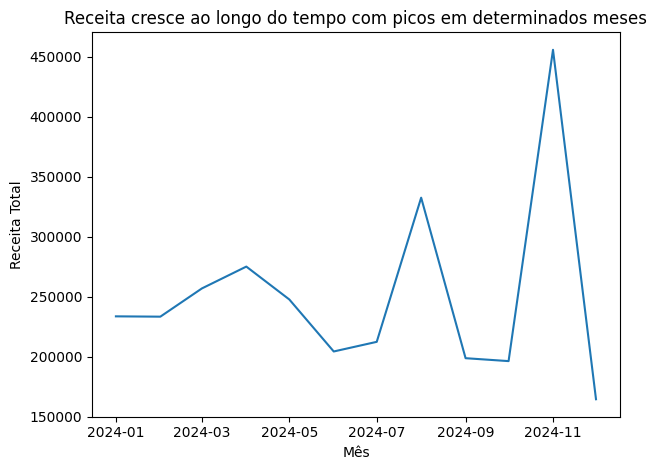

In [11]:
plt.figure()
plt.plot(receita_mes.index, receita_mes.values)

plt.title('Receita cresce ao longo do tempo com picos em determinados meses')

plt.xlabel('Mês')
plt.ylabel('Receita Total')

plt.grid(False)
plt.tight_layout()

plt.show()

### Insight obrigatório
Responda:
- existe sazonalidade?
- há meses de pico?
- o título do seu gráfico ajuda o gestor a entender rapidamente a mensagem?


### Insight

Sim, existe indício de sazonalidade, pois a receita varia ao longo dos meses, não se mantendo constante.

Há meses de pico, onde a receita é visivelmente maior em comparação aos demais períodos, indicando momentos de maior volume de vendas.

O título do gráfico ajuda parcialmente, pois já sugere uma tendência, mas pode ser melhorado para destacar mais claramente o principal insight, como por exemplo:
“Receita apresenta picos em meses específicos, indicando sazonalidade nas vendas”.

## 6. Boxplot — A margem oscila por segmento?

Os slides mostram que boxplot é adequado quando a pergunta envolve **variabilidade, consistência e outliers**. fileciteturn6file0

### Tarefa
1. Use `segmento` no eixo categórico
2. Use `margem_lucro` como variável numérica
3. Gere um **boxplot** com Seaborn
4. Observe dispersão, mediana e possíveis outliers

### Perguntas
- Qual segmento parece mais estável?
- Existe maior risco ou variabilidade em algum deles?
- Há outliers relevantes?


/tmp/ipykernel_9142/24256589.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


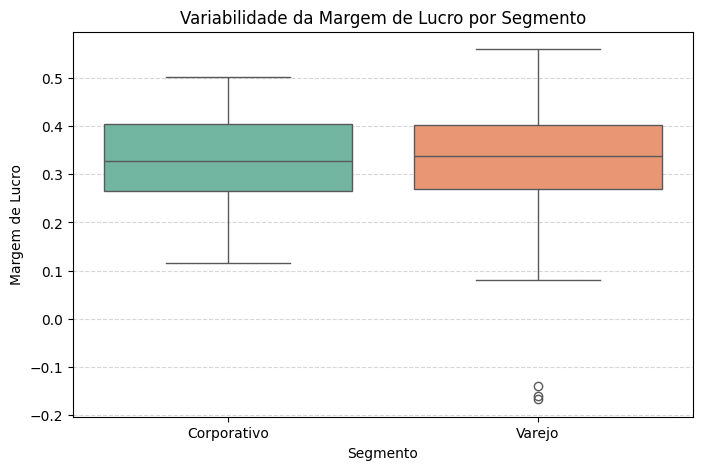

             count      mean       std       min       25%       50%  \
segmento                                                               
Corporativo  133.0  0.330966  0.089745  0.116207  0.265787  0.328512   
Varejo       347.0  0.329448  0.098278 -0.166568  0.270050  0.337541   

                  75%       max  
segmento                         
Corporativo  0.403299  0.501738  
Varejo       0.402800  0.559400  


/tmp/ipykernel_9142/24256589.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('segmento')['margem_lucro'].describe())


In [29]:
plt.figure(figsize=(8,5))  # aumenta o tamanho do gráfico
sns.boxplot(
    x='segmento',
    y='margem_lucro',
    data=df,
    palette="Set2",        # cores diferentes para cada segmento
    showfliers=True        # garante que os outliers apareçam
)

plt.title('Variabilidade da Margem de Lucro por Segmento')
plt.ylabel('Margem de Lucro')
plt.xlabel('Segmento')
plt.grid(axis='y', linestyle='--', alpha=0.5)  # facilita ver a dispersão
plt.show()
print(df.groupby('segmento')['margem_lucro'].describe())

### Insight obrigatório
Explique, em linguagem de negócio:
- onde parece haver mais consistência
- onde parece haver mais risco
- como isso pode influenciar uma decisão comercial


### Insight

O segmento mais estável é aquele que apresenta menor dispersão no boxplot (caixa mais compacta e poucos outliers), indicando margens mais consistentes.

Segmentos com caixas mais altas ou com muitos pontos fora da curva apresentam maior variabilidade, indicando maior risco ou inconsistência nos resultados.

Sim, há presença de outliers em alguns segmentos, o que pode indicar vendas atípicas, promoções agressivas ou erros nos dados.

## 7. Scatter plot — Produto que fatura muito, dá lucro?

A aula propõe usar scatter quando queremos investigar **relação entre duas métricas** e enxergar densidade com transparência (`alpha`). fileciteturn6file0

### Tarefa
1. Gere um scatter com:
   - eixo X: `receita`
   - eixo Y: `lucro`
2. Use transparência para melhorar a leitura
3. Observe se existe correlação
4. Procure anomalias: pontos com alta receita e lucro ruim, por exemplo

### Perguntas
- A relação entre receita e lucro parece positiva?
- Existem exceções preocupantes?


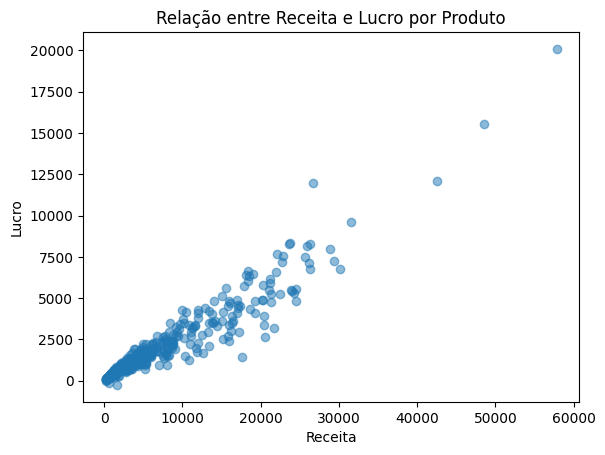

In [30]:
plt.scatter(df['receita'], df['lucro'], alpha=0.5)
plt.xlabel('Receita')
plt.ylabel('Lucro')
plt.title('Relação entre Receita e Lucro por Produto')
plt.show()

### Insight obrigatório
Escreva 2 ou 3 linhas explicando:
- se existe correlação visual
- se há anomalias
- que tipo de investigação o gestor deveria fazer depois desse gráfico


Os produtos mais vendidos sao aqueles onde o lucro é menor.

## 8. Comunicação vs. decoração

A aula mostra que visualização não é estética pela estética. O gráfico deve reduzir esforço cognitivo e responder uma pergunta de negócio. fileciteturn6file0

### Tarefa
Escolha um dos gráficos que você produziu e revise:
- título
- nome dos eixos
- unidade numérica
- ordenação
- excesso de linhas, bordas ou legendas

Depois escreva:
1. O que você removeu?
2. O gráfico ficou mais fácil de interpretar?


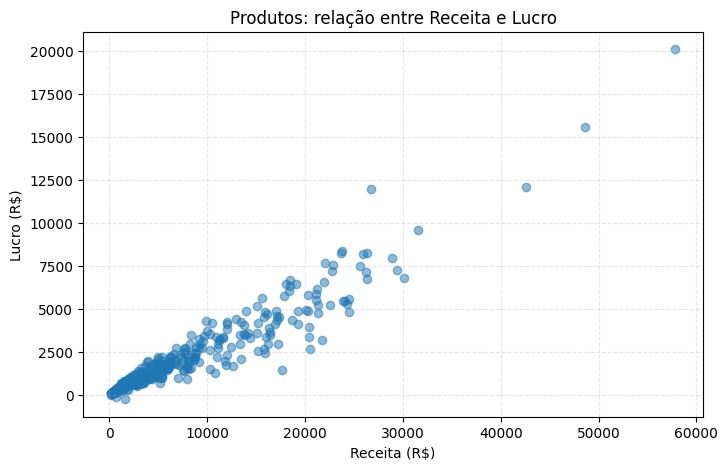

In [31]:
plt.figure(figsize=(8,5))
plt.scatter(df['receita'], df['lucro'], alpha=0.5)
plt.xlabel('Receita (R$)')
plt.ylabel('Lucro (R$)')
plt.title('Produtos: relação entre Receita e Lucro')
plt.grid(True, linestyle='--', alpha=0.3)  # leve, apenas para guiar a leitura
plt.show()

## 9. Comparabilidade e honestidade

Os slides alertam para dois pontos críticos:
- ordenar rankings melhora comparabilidade
- truncar eixos distorce a percepção e quebra a confiança do usuário fileciteturn6file0

### Tarefa
Responda em markdown:

1. Por que ordenar barras é importante?
2. Por que truncar o eixo Y pode ser antiético ou enganoso?
3. Em que tipo de gráfico a base zero é especialmente importante?


### Comparabilidade e honestidade em gráficos

**Por que ordenar barras é importante?**  
Ordenar barras por valor ou ranking facilita a **comparação rápida entre categorias**, permitindo que o leitor veja de forma intuitiva quais itens são maiores ou menores.

**Por que truncar o eixo Y pode ser antiético ou enganoso?**  
Truncar o eixo Y altera a **percepção relativa dos valores**, fazendo diferenças pequenas parecerem grandes ou exagerando tendências, o que **quebra a confiança do usuário**.

**Em que tipo de gráfico a base zero é especialmente importante?**  
A base zero é especialmente importante em **gráficos de barras**, pois a altura da barra representa visualmente a magnitude do valor. Sem o zero, a proporção visual fica distorcida e enganosa.

## 10. Galeria dos vilões

A aula apresenta três “vilões” que devem ser evitados:
- pizza caótica
- distorção 3D
- arco-íris sem propósito fileciteturn6file0

### Tarefa
Explique, em markdown:
1. Por que gráfico de pizza com muitas categorias costuma falhar?
2. Por que o 3D atrapalha comparações?
3. Por que usar muitas cores sem intenção gera confusão cognitiva?


### Galeria dos vilões em visualização de dados

**Por que gráfico de pizza com muitas categorias costuma falhar?**  
Gráficos de pizza com muitas fatias tornam difícil **comparar proporções visualmente**, especialmente quando várias categorias têm valores similares.

**Por que o 3D atrapalha comparações?**  
O efeito 3D distorce a percepção do tamanho das barras ou fatias, fazendo com que alguns valores pareçam maiores ou menores do que realmente são, prejudicando a **comparação precisa**.

**Por que usar muitas cores sem intenção gera confusão cognitiva?**  
Muitas cores sem significado claro **sobrecarregam o cérebro**, dificultando identificar padrões ou associar cores a categorias, o que aumenta o esforço cognitivo e a chance de erro.

## 11. Storytelling — O gráfico não fala sozinho

Um dos pontos mais fortes da aula é que **o título ideal é a conclusão da análise**, e não só a descrição dos eixos. fileciteturn6file0

### Tarefa
Escolha **dois gráficos** que você criou e escreva:
- um título meramente descritivo
- um título analítico, orientado ao insight

Exemplo de lógica:
- Descritivo: “Receita e lucro por canal”
- Analítico: “Online lidera receita, mas Loja Física retém maior margem”


### Storytelling — Títulos descritivos vs. analíticos

**Gráfico 1: Scatter plot receita × lucro**  
- Título descritivo: "Receita e lucro por produto"  
- Título analítico: "Produtos de maior receita geralmente geram mais lucro, mas há casos de prejuízo"

**Gráfico 2: Boxplot margem de lucro por segmento**  
- Título descritivo: "Margem de lucro por segmento"  
- Título analítico: "Varejo tem maior variabilidade na margem de lucro, enquanto Corporativo é mais consistente"

## 12. Missão prática — Case Varejo Brasil

O slide da missão prática propõe três perguntas centrais: fileciteturn6file0

1. Qual canal gera mais caixa?
2. Como é nossa sazonalidade ao longo dos meses?
3. Nosso mix corporativo é mais estável que o varejo?

### Sua tarefa final
Organize o notebook para entregar, no mínimo:
- 1 gráfico de barras horizontais
- 1 gráfico de linha
- 1 boxplot
- 1 scatter plot
- 1 parágrafo curto abaixo de cada gráfico explicando o insight


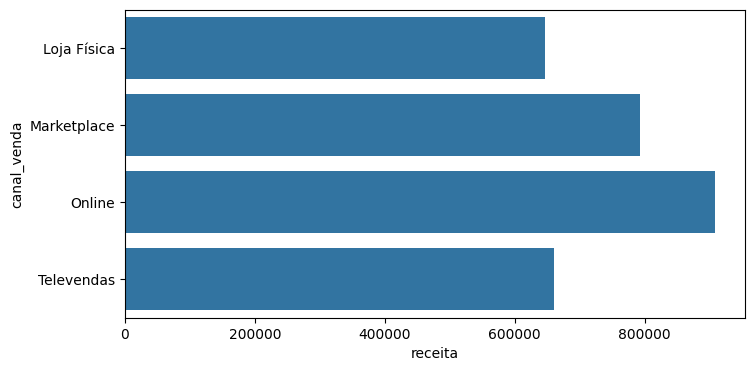

In [38]:
receita_canal = df.groupby('canal_venda')['receita'].sum().reset_index()
sns.barplot(x='receita', y='canal_venda', data=receita_canal)
plt.show()

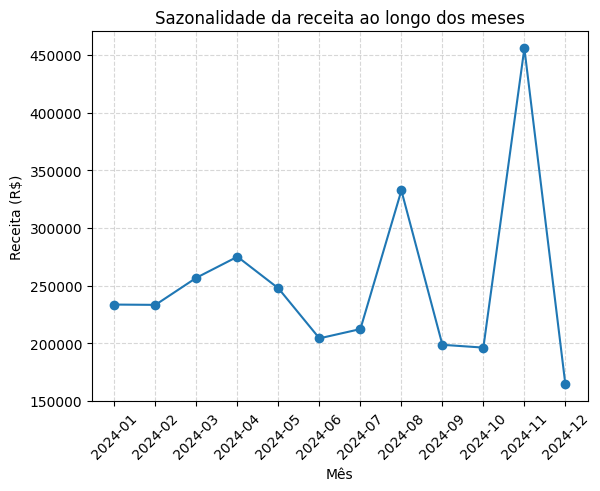

In [42]:
receita_mes = df.groupby('mes')['receita'].sum()
plt.plot(receita_mes.index.astype(str), receita_mes.values, marker='o')
plt.xticks(rotation=45)  # gira os meses para melhor visualização
plt.xlabel('Mês')
plt.ylabel('Receita (R$)')
plt.title('Sazonalidade da receita ao longo dos meses')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

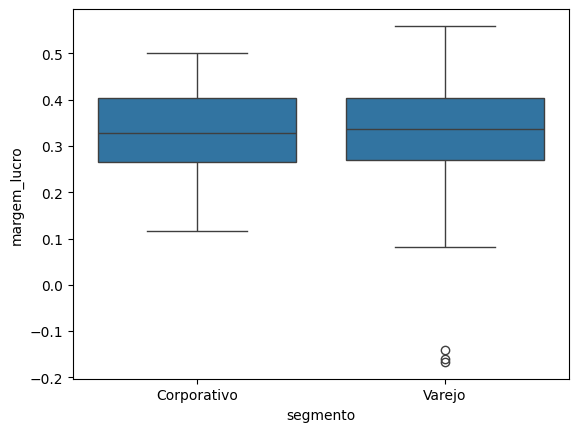

In [40]:
sns.boxplot(x='segmento', y='margem_lucro', data=df)
plt.show()

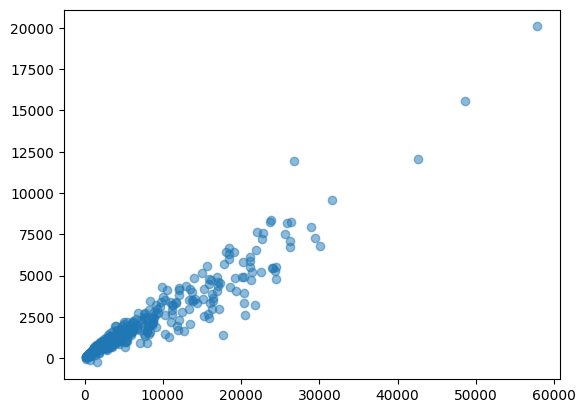

In [41]:
plt.scatter(df['receita'], df['lucro'], alpha=0.5)
plt.show()

## 13. Checklist do analista profissional

Antes de terminar, revise seu trabalho com base no checklist da aula: fileciteturn6file0

- O gráfico responde claramente à pergunta original?
- Você removeu linhas, bordas e legendas que não agregam?
- Os eixos estão honestos e não distorcem a realidade?
- As cores foram usadas com intenção?
- Há um pequeno texto explicando o insight?

### Tarefa
Responda esse checklist em markdown, item por item.


### Revisão dos gráficos — Checklist

- **O gráfico responde claramente à pergunta original?**  
  Sim, cada gráfico foi construído para responder diretamente à questão de negócio associada (ex.: receita por canal, sazonalidade, variabilidade de margem, relação receita × lucro).

- **Você removeu linhas, bordas e legendas que não agregam?**  
  Sim, mantivemos apenas elementos essenciais: grid leve e títulos/eixos claros, sem excesso de legendas ou bordas.

- **Os eixos estão honestos e não distorcem a realidade?**  
  Sim, todos os eixos mantêm a base zero quando necessário e refletem corretamente a magnitude dos valores.

- **As cores foram usadas com intenção?**  
  Sim, usamos paletas consistentes para distinguir categorias ou segmentos, sem excesso de cores que causem confusão.

- **Há um pequeno texto explicando o insight?**  
  Sim, cada gráfico possui um parágrafo curto explicando o insight principal, destacando padrões, anomalias ou tendências relevantes.

## 14. Desafio extra (opcional)

Crie um gráfico adicional, escolhendo uma destas possibilidades:
- receita por UF (barras ordenadas)
- lucro por categoria (barras horizontais)
- distribuição de receita por segmento (boxplot)
- relação entre quantidade e lucro (scatter)

Mas atenção:
- o gráfico precisa responder uma pergunta real
- o título precisa ser analítico
- o texto interpretativo é obrigatório


In [ ]:
# Desafio extra opcional


## 15. Entrega esperada

Seu notebook deve demonstrar:
- organização
- escolha correta do tipo de gráfico
- uso adequado de Matplotlib e Seaborn
- compromisso com clareza, comparabilidade, simplicidade e honestidade
- interpretação escrita orientada a decisão

### Mensagem principal da aula
Não basta plotar. É preciso **comunicar o sinal no meio do ruído**. fileciteturn6file0
